# Bài tập thực hành tuần 4

> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

In [107]:
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import heapq
import sys
from time import perf_counter
from math import log2

### Bài tập 1:
**Câu hỏi**:

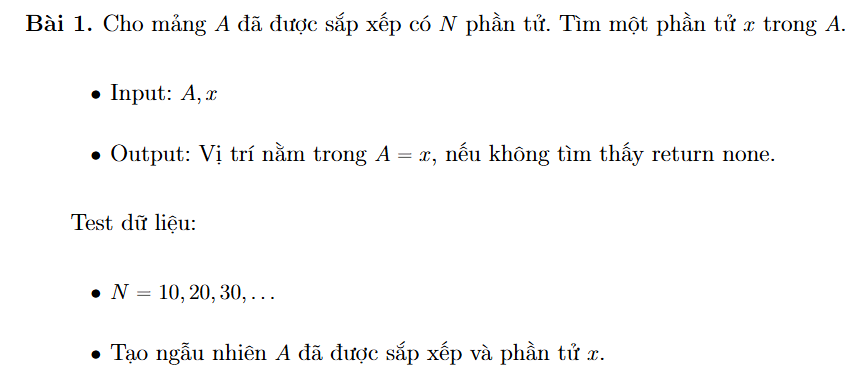

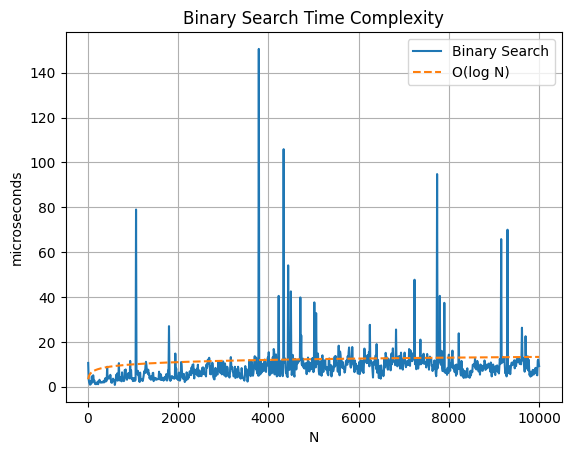

In [110]:
def RNG_A(N):
    return sorted(random.sample(range(1, N*100 + 1), N))

def binary_search(A, target):
    l, r = 0, len(A)-1
    while l <= r:
        m = (l + r) // 2
        if A[m] == target:
            return m

        if A[m] > target:
            r = m - 1
        else:
            l = m + 1

    return None

T = []
N = [10*i for i in range(1, 1001)]
for n in N:
    A = RNG_A(n)
    x = random.choice(A)
    
    tic = perf_counter()
    index = binary_search(A, x)
    T.append(perf_counter() - tic)
    
    T[-1] = T[-1] * 1e6 
     
    # if index:
    #     print(f'Found {x} at {index}')
    # else:
    #     print('Not found')
        

plt.plot(N, T, label='Binary Search')
plt.plot(N, [log2(n) for n in N], label='O(log N)', linestyle='--')
plt.xlabel('N')
plt.ylabel('microseconds')
plt.title('Binary Search Time Complexity')
plt.legend()
plt.grid()
plt.show()

Hàm `RNG_A(N)` tạo ra một mảng gồm N số nguyên dương duy nhất được sắp xếp theo thứ tự tăng dần. 
```python 
def RNG_A(N):
    return sorted(random.sample(range(1, N*100 + 1), N))
```

Hàm `binary_search(A, target)` thực hiện tìm kiếm nhị phân trên mảng A để tìm vị trí của target bằng cách chia đôi mảng liên tục. Bắt đầu với hai con trỏ l và r đại diện cho đầu và cuối của mảng, hàm sẽ tính toán vị trí giữa m và so sánh giá trị tại đó với target thành 3 trường hợp sau: <br>
 - Nếu tìm thấy target, hàm trả về vị trí m. 
 - Nếu giá trị tại m lớn hơn target, hàm sẽ thu hẹp phạm vi tìm kiếm về phía bên trái bằng cách cập nhật r = m - 1. <br>
 - Nếu giá trị tại m nhỏ hơn target, hàm sẽ thu hẹp phạm vi tìm kiếm về phía bên phải bằng cách cập nhật l = m + 1. 

Quá trình này tiếp tục cho đến khi l vượt qua r (target không tồn tại trong mảng) và sau đó hàm trả về None.

```python
def binary_search(A, target):
    l, r = 0, len(A)-1
    while l <= r:
        m = (l + r) // 2
        if A[m] == target:
            return m

        if A[m] > target:
            r = m - 1
        else:
            l = m + 1

    return None
```

Chương trình chính thực hiện các bước sau: <br>
1. Tạo một danh sách rỗng T để lưu trữ thời gian thực thi của thuật toán tìm kiếm nhị phân. <br>
2. Tạo một danh sách N chứa các kích thước của mảng từ 10 đến 10,000 với bước nhảy là 10. <br>
3. Với mỗi kích thước n trong N, chương trình sẽ tạo ra một mảng A bằng cách gọi hàm RNG_A(n) và chọn ngẫu nhiên một phần tử x từ mảng A. <br>
4. Đo thời gian thực thi của hàm binary_search(A, x) và lưu trữ thời gian này vào danh sách T sau khi chuyển đổi sang micro giây. <br>

```python
T = []
N = [10*i for i in range(1, 1001)]
for n in N:
    A = RNG_A(n)
    x = random.choice(A)
    
    tic = perf_counter()
    index = binary_search(A, x)
    T.append(perf_counter() - tic)
    
    T[-1] = T[-1] * 1e6 
```

Cuối cùng, chương trình vẽ biểu đồ thời gian thực thi của thuật toán tìm kiếm nhị phân so với đường O(log N). Trục x đại diện cho kích thước của mảng N, trong khi trục y đại diện cho thời gian thực thi trung bình tính bằng micro giây. Biểu đồ cũng bao gồm một đường đứt nét để minh họa độ phức tạp O(log N) để so sánh với kết quả thực nghiệm.
```python
plt.plot(N, T, label='Binary Search')
plt.plot(N, [log2(n) for n in N], label='O(log N)', linestyle='--')
plt.xlabel('N')
plt.ylabel('microseconds')
plt.title('Binary Search Time Complexity')
plt.legend()
plt.grid()
plt.show() 
```
Kết quả cho thấy đồ thị thời gian thực thi của thuật toán chạy gần giống với đường O(log N), chứng tỏ rằng thuật toán tìm kiếm nhị phân có độ phức tạp thời gian là O(log N).

### Bài tập 2:
**Câu hỏi**:

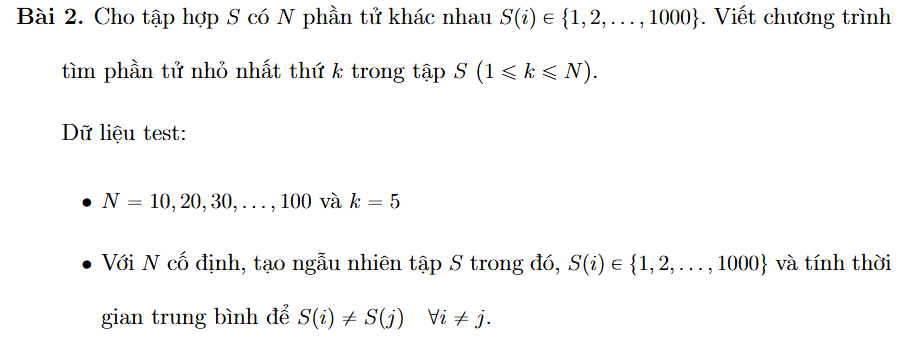

N = 10, k-smallest = 541, avg time = 7.41380244 microseconds
N = 20, k-smallest = 58, avg time = 12.71889871 microseconds
N = 30, k-smallest = 178, avg time = 14.10649763 microseconds
N = 40, k-smallest = 108, avg time = 17.52260001 microseconds
N = 50, k-smallest = 187, avg time = 23.61380402 microseconds
N = 60, k-smallest = 109, avg time = 35.79130233 microseconds
N = 70, k-smallest = 42, avg time = 46.62450100 microseconds
N = 80, k-smallest = 68, avg time = 49.29800192 microseconds
N = 90, k-smallest = 35, avg time = 70.13790193 microseconds
N = 100, k-smallest = 43, avg time = 80.38050332 microseconds


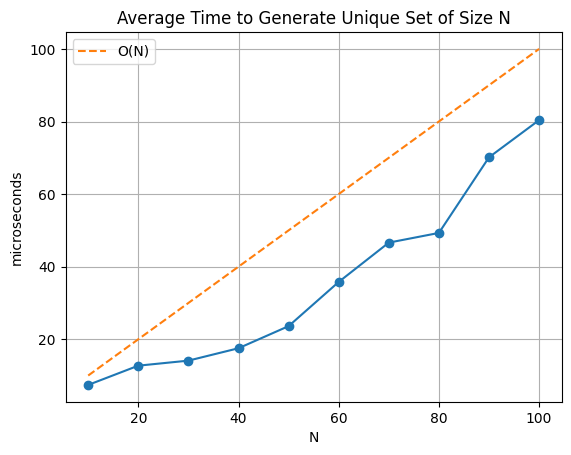

In [ ]:
def RNG_S(N):
    return random.sample(range(1, 1001), N)

def find_k_smallest(S, k):
    if not S:
        return None
        
    pivot = random.choice(S)
    
    left = [x for x in S if x < pivot]   
    mid = [x for x in S if x == pivot]   
    right = [x for x in S if x > pivot]
    
    L = len(left)
    M = len(mid)
    
    if k <= L:
        return find_k_smallest(left, k)
        
    elif k > L + M:
        return find_k_smallest(right, k - L - M)
        
    else:
        return mid[0]

k = 5
num_trials = 1000 
avg_time_arr = []
for N in range(10, 101, 10):
    total_time = 0
    
    for _ in range(num_trials):
        start_time = perf_counter()
        S = RNG_S(N)
        total_time += (perf_counter() - start_time)
        
    avg_time = total_time / num_trials
    avg_time *= 1e6
    avg_time_arr.append(avg_time)
    
    sample_S = RNG_S(N)
    result = find_k_smallest(sample_S, k)
    
    print(f'{N = }, k-smallest = {result}, avg time = {avg_time:.8f} microseconds')
    
plt.plot(range(10, 101, 10), avg_time_arr, marker='o')
plt.plot(range(10, 101, 10), [N for N in range(10, 101, 10)], label='O(N)', linestyle='--')
plt.legend()
plt.xlabel('N')
plt.ylabel('microseconds')
plt.title('Average Time to Generate Unique Set of Size N')
plt.grid()
plt.show()

Hàm `RNG_S(N)` tạo ra một tập hợp gồm N số nguyên dương duy nhất được chọn ngẫu nhiên từ khoảng 1 đến 1000. Hàm này sử dụng `random.sample()` để đảm bảo rằng tất cả các phần tử trong tập hợp là duy nhất.
```python
def RNG_S(N):
    return random.sample(range(1, 1001), N)
```

Hàm `find_k_smallest(S, k)` sử dụng thuật toán Quickselect để tìm phần tử nhỏ thứ k trong tập hợp S. Thuật toán này hoạt động bằng cách chọn một phần tử pivot ngẫu nhiên từ S và phân chia S thành ba phần: left chứa các phần tử nhỏ hơn pivot, mid chứa các phần tử bằng pivot, và right chứa các phần tử lớn hơn pivot. Sau đó, thuật toán sẽ quyết định xem phần tử nhỏ thứ k nằm ở đâu dựa trên kích thước của left và mid:
- Nếu k nhỏ hơn hoặc bằng kích thước của left, phần tử nhỏ thứ k nằm trong left, và thuật toán sẽ đệ quy tìm kiếm trong left.
- Nếu k lớn hơn kích thước của left cộng với kích thước của mid, phần tử nhỏ thứ k nằm trong right, và thuật toán sẽ đệ quy tìm kiếm trong right với k được điều chỉnh lại.
- Nếu k nằm trong khoảng giữa left và mid, phần tử nhỏ thứ k chính là pivot, và thuật toán sẽ trả về giá trị của pivot.
```python
def find_k_smallest(S, k):
    if not S:
        return None
        
    pivot = random.choice(S)
    
    left = [x for x in S if x < pivot]   
    mid = [x for x in S if x == pivot]   
    right = [x for x in S if x > pivot]
    
    L = len(left)
    M = len(mid)
    
    if k <= L:
        return find_k_smallest(left, k)
        
    elif k > L + M:
        return find_k_smallest(right, k - L - M)
        
    else:
        return mid[0]
```
Chương trình chính thực hiện các bước sau:
1. Đặt giá trị k = 5 để tìm phần tử nhỏ thứ 5 trong tập hợp.
2. Đặt số lần thử nghiệm num_trials = 1000 để tính thời gian trung bình chính xác hơn.
3. Tạo một danh sách avg_time_arr để lưu trữ thời gian trung bình cho mỗi giá trị N.
4. Vòng lặp for chạy qua các giá trị N từ 10 đến 100 (bước nhảy 10). Trong mỗi vòng lặp:
   - Đặt total_time = 0 để tích lũy thời gian thực thi cho num_trials lần chạy.
   - Vòng lặp for thứ hai chạy num_trials lần, trong đó:
     - Tạo một tập hợp S ngẫu nhiên với N phần tử bằng cách gọi RNG_S(N).
     - Đo thời gian bắt đầu và kết thúc của việc tạo tập hợp S, và cộng dồn thời gian vào total_time.
   - Tính thời gian trung bình avg_time bằng cách chia total_time cho num_trials và chuyển đổi sang micro giây.
   - Lưu avg_time vào avg_time_arr.
   - Tạo một tập hợp mẫu sample_S và tìm phần tử nhỏ thứ k trong sample_S bằng cách gọi find_k_smallest(sample_S, k).
   - In ra giá trị N, phần tử nhỏ thứ k tìm được, và thời gian trung bình.
```python
k = 5
num_trials = 1000
avg_time_arr = []
for N in range(10, 101, 10):
    total_time = 0
    
    for _ in range(num_trials):
        start_time = perf_counter()
        S = RNG_S(N)
        total_time += (perf_counter() - start_time)
        
    avg_time = total_time / num_trials
    avg_time *= 1e6
    avg_time_arr.append(avg_time)
    
    sample_S = RNG_S(N)
    result = find_k_smallest(sample_S, k)
    
    print(f'{N = }, k-smallest = {result}, avg time = {avg_time:.8f} microseconds')
```
Cuối cùng, chương trình vẽ biểu đồ thời gian trung bình để tạo ra một tập hợp duy nhất của kích thước N. Trục x đại diện cho kích thước của tập hợp N, trong khi trục y đại diện cho thời gian trung bình tính bằng micro giây. Biểu đồ cũng bao gồm một đường đứt nét để minh họa độ phức tạp O(N) để so sánh với kết quả thực nghiệm.
```python
plt.plot(range(10, 101, 10), avg_time_arr, marker='o')
plt.plot(range(10, 101, 10), [N for N in range(10, 101, 10)], label='O(N)', linestyle='--')
plt.legend()
plt.xlabel('N')
plt.ylabel('microseconds')
plt.title('Average Time to Generate Unique Set of Size N')
plt.grid()
plt.show()
```
Kết quả cho thấy thời gian trung bình để tạo ra một tập hợp duy nhất của kích thước N tăng gần giống với O(N) nhưng mà nhanh hơn O(N) (có thể là do CPU tối ưu hóa và tính toán song song), chứng tỏ rằng độ phức tạp thời gian của thuật toán này là O(N).